_Segmentation using U-Net_

- Brain Tumor Segmentation using U-Net on LGG MRI Dataset
    - Train a Simple U-Net Model for Brain Tumor Segmentation
        1. Explore and learn about different preprocessing steps in medical imaging, specifically for MRI scans.
        1. Apply suitable preprocessing steps such as normalization, resizing, and data augmentation for this segmentation task.
        1. Build and train a U-Net model using basic layers from the framework for brain tumor segmentation.
        1. Test the model on the test set using suitable evaluation metrics such as Dice coefficient and IoU.

- Dataset: LGG MRI Dataset
    - Preprocess the dataset by normalizing and resizing the images. Split the dataset into training, validation, and testing sets (e.g., 80% training, 10% validation, 10% testing).

- Dataset Link : https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
- Dataset Zip Link: https://drive.google.com/drive/folders/1F7pobjXSJk99EUtph3_gdq_b0ZgaG30Y?usp=sharing

In [2]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os

2025-04-07 10:19:35.609550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744021178.096154   13159 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744021178.754824   13159 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-07 10:19:45.526113: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


(64, 64, 3)
(64, 64, 3)


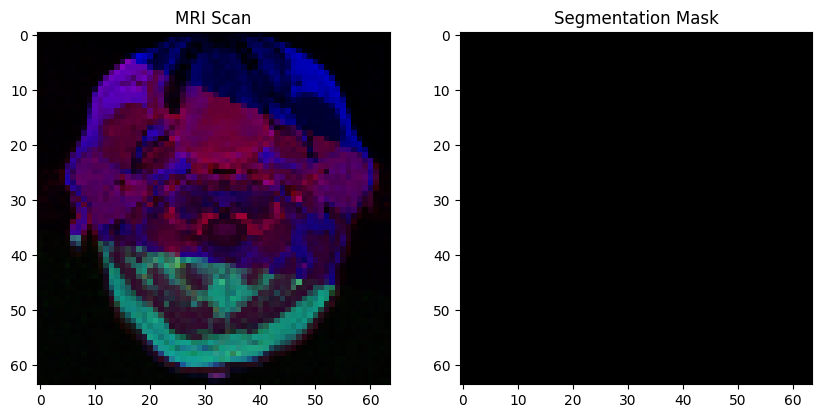

In [3]:
def load_image(image_path, mask_path):
    #Image
    image=cv2.imread(image_path,cv2.IMREAD_UNCHANGED)
    image=cv2.resize(image,(64,64))
    image=image.astype(np.float32)/255.0

    if len(image.shape)==2:
        image=cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)

    #Mask
    mask=cv2.imread(mask_path,cv2.IMREAD_UNCHANGED)
    mask=cv2.resize(mask,(64,64))
    mask=mask.astype(np.float32)/255.0

    if len(mask.shape)==2:
        mask=cv2.cvtColor(mask,cv2.COLOR_GRAY2RGB)


    return image, mask

image_path = "mri-dataset/train/images/TCGA_CS_4941_19960909_1.tif"
mask_path = "mri-dataset/train/masks/TCGA_CS_4941_19960909_1_mask.tif"

image,mask = load_image(image_path,mask_path)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].set_title("MRI Scan")
ax[1].imshow(mask)
ax[1].set_title("Segmentation Mask")
print(image.shape)
print(mask.shape)
plt.show()

In [4]:
train_images = sorted(os.listdir("mri-dataset/train/images"))
train_masks = sorted(os.listdir("mri-dataset/train/masks"))

def data_generator(src_dir, image_list, mask_list, batch_size=16):
    images=[]
    masks=[]
    for img, mask in zip(image_list, mask_list):
        img_path = os.path.join(os.path.join(src_dir, "images"),img)
        mask_path = os.path.join(os.path.join(src_dir, "masks"),mask)

        image, mask = load_image(img_path, mask_path)

        # image, mask = augment(image, mask)

        images.append(image)
        masks.append(mask)

    return tf.data.Dataset.from_tensor_slices((images,masks)).batch(batch_size).shuffle(100)

train_dataset = data_generator("mri-dataset/train",train_images,train_masks)

I0000 00:00:1744021413.077910   13159 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
val_images=sorted(os.listdir("mri-dataset/val/images"))
val_masks=sorted(os.listdir("mri-dataset/val/masks"))
val_dataset=data_generator("mri-dataset/val",val_images,val_masks)

In [6]:
test_images=sorted(os.listdir("mri-dataset/test/images"))
test_masks=sorted(os.listdir("mri-dataset/test/masks"))
test_dataset=data_generator("mri-dataset/test",test_images,test_masks)

Image shape: (64, 64, 3)
Mask shape: (64, 64, 3)


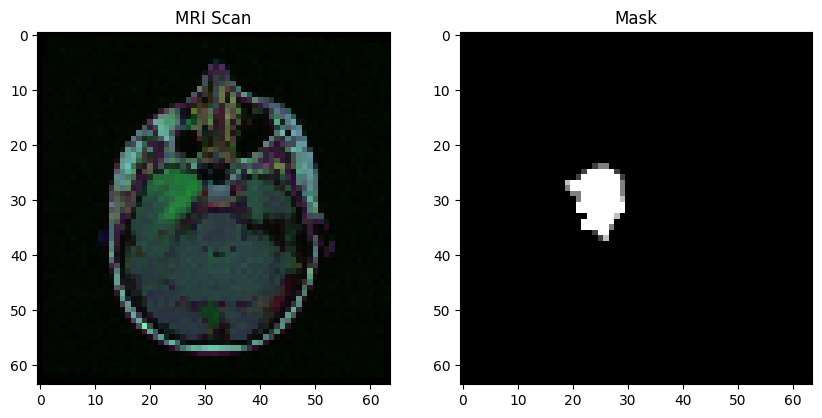

Image shape: (64, 64, 3)
Mask shape: (64, 64, 3)


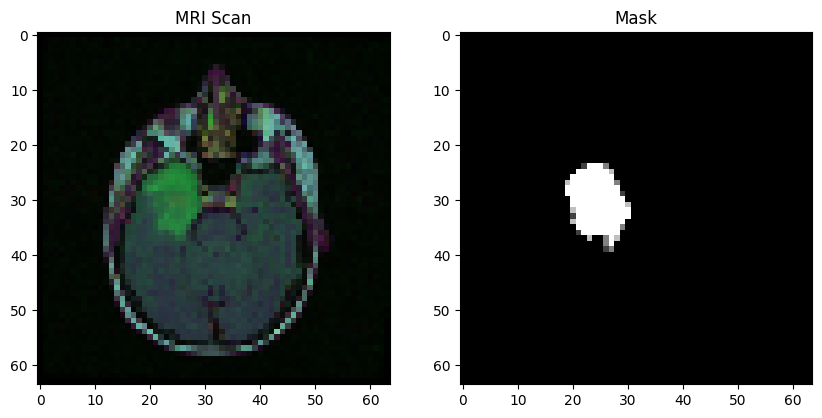

2025-04-07 10:24:55.753627: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
for data in train_dataset.take(1):
    for i in range(0,int(16/8)):
        img,mask=data
        print(f"Image shape: {img[i].shape}")
        print(f"Mask shape: {mask[i].shape}")
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img[i])
        ax[0].set_title("MRI Scan")
        ax[1].imshow(mask[i])
        ax[1].set_title("Mask")
        plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, Model

IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_CHANNELS = 3

def unet_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)

    # Decoder (Upsampling)
    u5 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c7)

    # Output Layer
    outputs = layers.Conv2D(3, (1, 1), activation='sigmoid')(c7)

    model = Model(inputs, outputs)
    return model

# Create U-Net model
unet = unet_model()
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 256) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 512) │  1,180,160 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,697,475 (29.36 MB)

 Trainable params: 7,697,475 (29.36 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

unet.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=dice_loss,
    metrics=[dice_coefficient, 'accuracy']
)
BATCH_SIZE = 16

In [37]:
EPOCHS = 20

history = unet.fit(train_dataset, epochs=EPOCHS, validation_data=val_dataset)

Epoch 1/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 1.0000 - dice_coefficient: 0.2668 - loss: 0.7342 - val_accuracy: 1.0000 - val_dice_coefficient: 0.0976 - val_loss: 0.8995
Epoch 2/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 1.0000 - dice_coefficient: 0.2039 - loss: 0.7978 - val_accuracy: 1.0000 - val_dice_coefficient: 0.0976 - val_loss: 0.8995
Epoch 3/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 1.0000 - dice_coefficient: 0.2602 - loss: 0.7409 - val_accuracy: 1.0000 - val_dice_coefficient: 0.0976 - val_loss: 0.8995
Epoch 4/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 1.0000 - dice_coefficient: 0.2529 - loss: 0.7477 - val_accuracy: 1.0000 - val_dice_coefficient: 0.0976 - val_loss: 0.8995
Epoch 5/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 1.0000 - dice_coefficient: 0.2706 - loss: 0.7308 - val_accuracy: 1.0000 - val_dice_coefficient: 0.0976 - val_loss: 0.8995
Epoch 6/20
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy:

In [38]:
unet.save_weights("unet.weights.h5")

In [10]:
unet.load_weights("unet.weights.h5")

/mnt/c/Users/Falcon/Desktop/DL/tf_env/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [11]:
test_loss, test_dice, test_acc = unet.evaluate(test_dataset)
print(f"Test Dice Coefficient: {test_dice:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

I0000 00:00:1744021503.025087   19007 service.cc:148] XLA service 0x7f10fc00d790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744021503.026105   19007 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-04-07 10:25:03.526264: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1744021504.080821   19007 cuda_dnn.cc:529] Loaded cuDNN version 90300


15/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - dice_coefficient: 0.1708 - loss: 0.8292 

I0000 00:00:1744021516.190675   19007 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 1.0000 - dice_coefficient: 0.1835 - loss: 0.8186
Test Dice Coefficient: 0.2021
Test Accuracy: 1.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


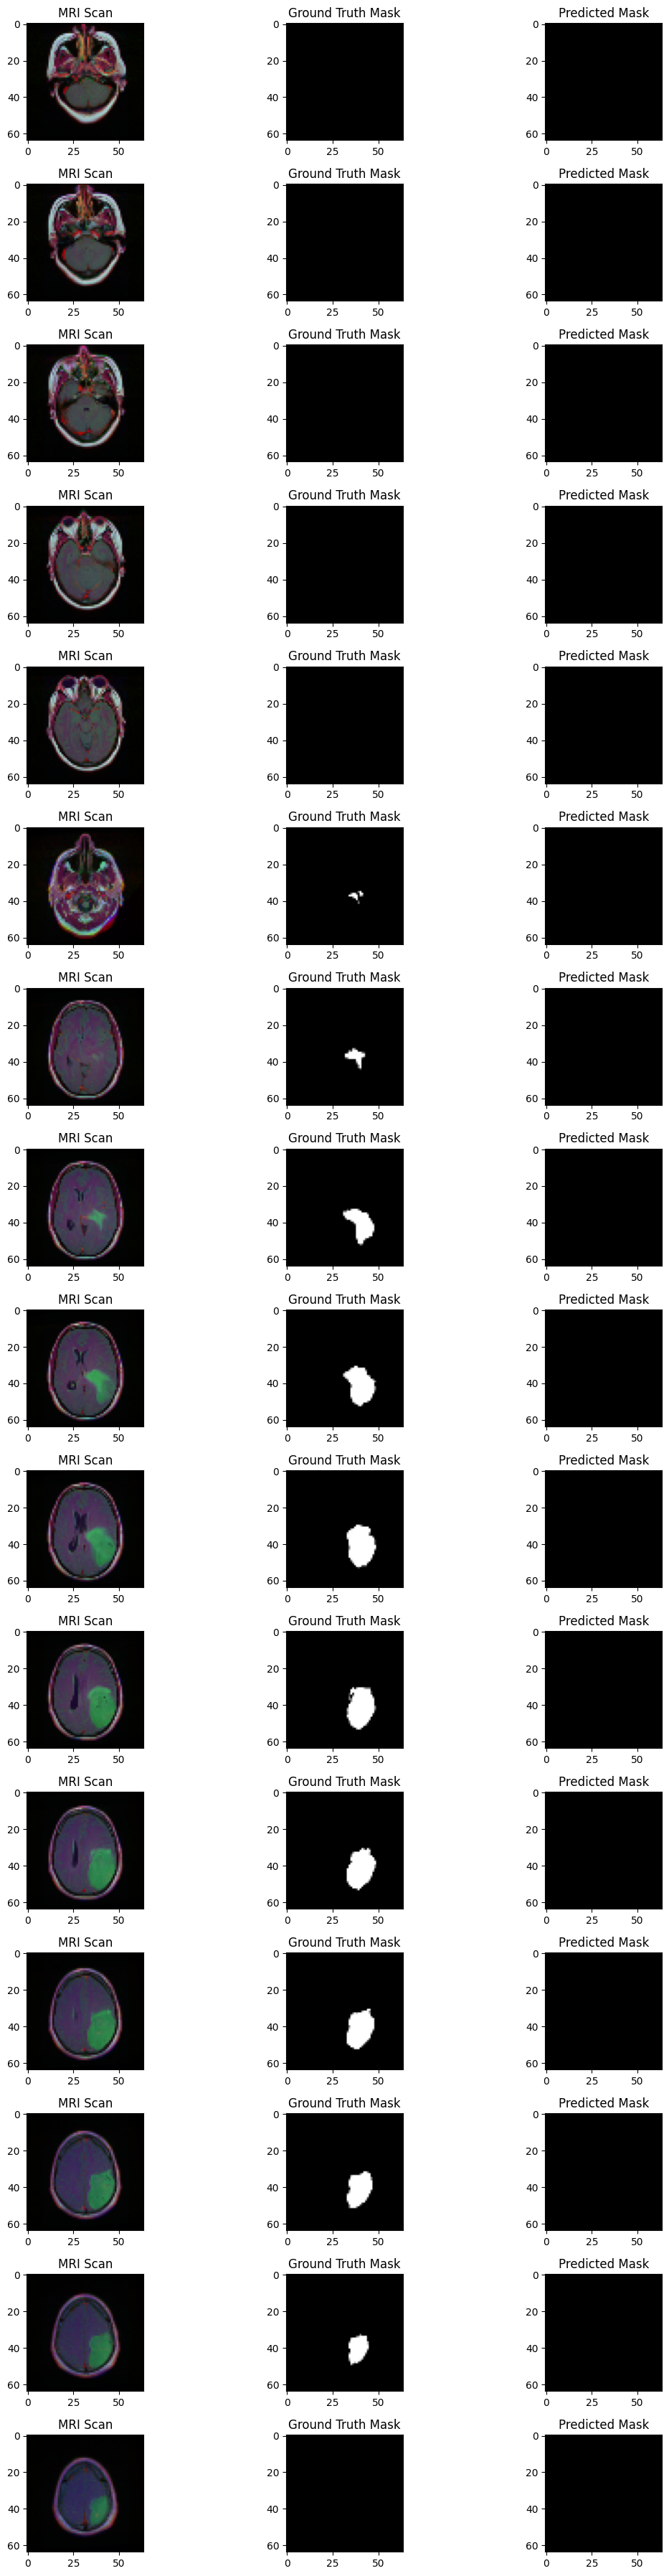

2025-04-07 10:25:25.734749: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
for image, mask in test_dataset.take(1):
    pred_mask = unet.predict(image)

    fig, ax = plt.subplots(BATCH_SIZE, 3, figsize=(12, 36))
    for i in range(BATCH_SIZE):
        ax[i,0].imshow(image[i])
        ax[i,0].set_title("MRI Scan")
        ax[i,1].imshow(mask[i])
        ax[i,1].set_title("Ground Truth Mask")
        ax[i,2].imshow(pred_mask[i])
        ax[i,2].set_title("Predicted Mask")
    plt.tight_layout()
    plt.show()